# Статистика 
<a id="top"></a>

## Оглавление

[1. Новые данные](#task-1)   
[2. Бутстрап и доверительные интервалы](#task-2)  
[3. Центральная предельная теорема и доверительные интервалы](#task-3)  
[4. T-распределение](#task-4)  
[5. T-критерий](#task-5)  
[6. U-критерий Мана–Уитни](#task-6)  
[7. Корреляция Пирсона](#task-7)  
[8. Корреляция Спирмена](#task-8)  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm
import math

<a id="task-1"></a>
## 1. Новые данные

#### 1. Загрузка данных

In [ ]:
df = pd.read_excel("../materials/dataset_vaccine.xlsx")
df.head()

,id,area_name,state,area_type,vaccine_hesitant,case_rate,higher_edu,median_age
0,1001,"Autauga County, Alabama",Alabama,Urban,52.746604,18038.06771,57.3,38.2
1,1003,"Baldwin County, Alabama",Alabama,Urban,40.538628,16537.29823,63.3,43.0
2,1005,"Barbour County, Alabama",Alabama,Rural,49.169570,14733.15172,39.0,40.4
3,1007,"Bibb County, Alabama",Alabama,Rural,60.516210,19649.34541,35.8,40.9
4,1009,"Blount County, Alabama",Alabama,Rural,64.666413,18367.72657,47.7,40.7


#### 2. Типы данных и попуски

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                3035 non-null   int64  
 1   area_name         3035 non-null   object 
 2   state             3035 non-null   object 
 3   area_type         3035 non-null   object 
 4   vaccine_hesitant  3035 non-null   float64
 5   case_rate         3035 non-null   float64
 6   higher_edu        3035 non-null   float64
 7   median_age        3035 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 189.8+ KB


In [ ]:
df.shape

(3035, 8)

In [ ]:
df.columns.tolist()

['id',
 'area_name',
 'state',
 'area_type',
 'vaccine_hesitant',
 'case_rate',
 'higher_edu',
 'median_age']

#### 3. Количество городских и сельских

In [ ]:
df["area_type"].value_counts()

area_type
Rural    1930
Urban    1105
Name: count, dtype: int64

#### 4. Распределения для столбцов vaccine_hesitant, case_rate, higher_edu и median_age

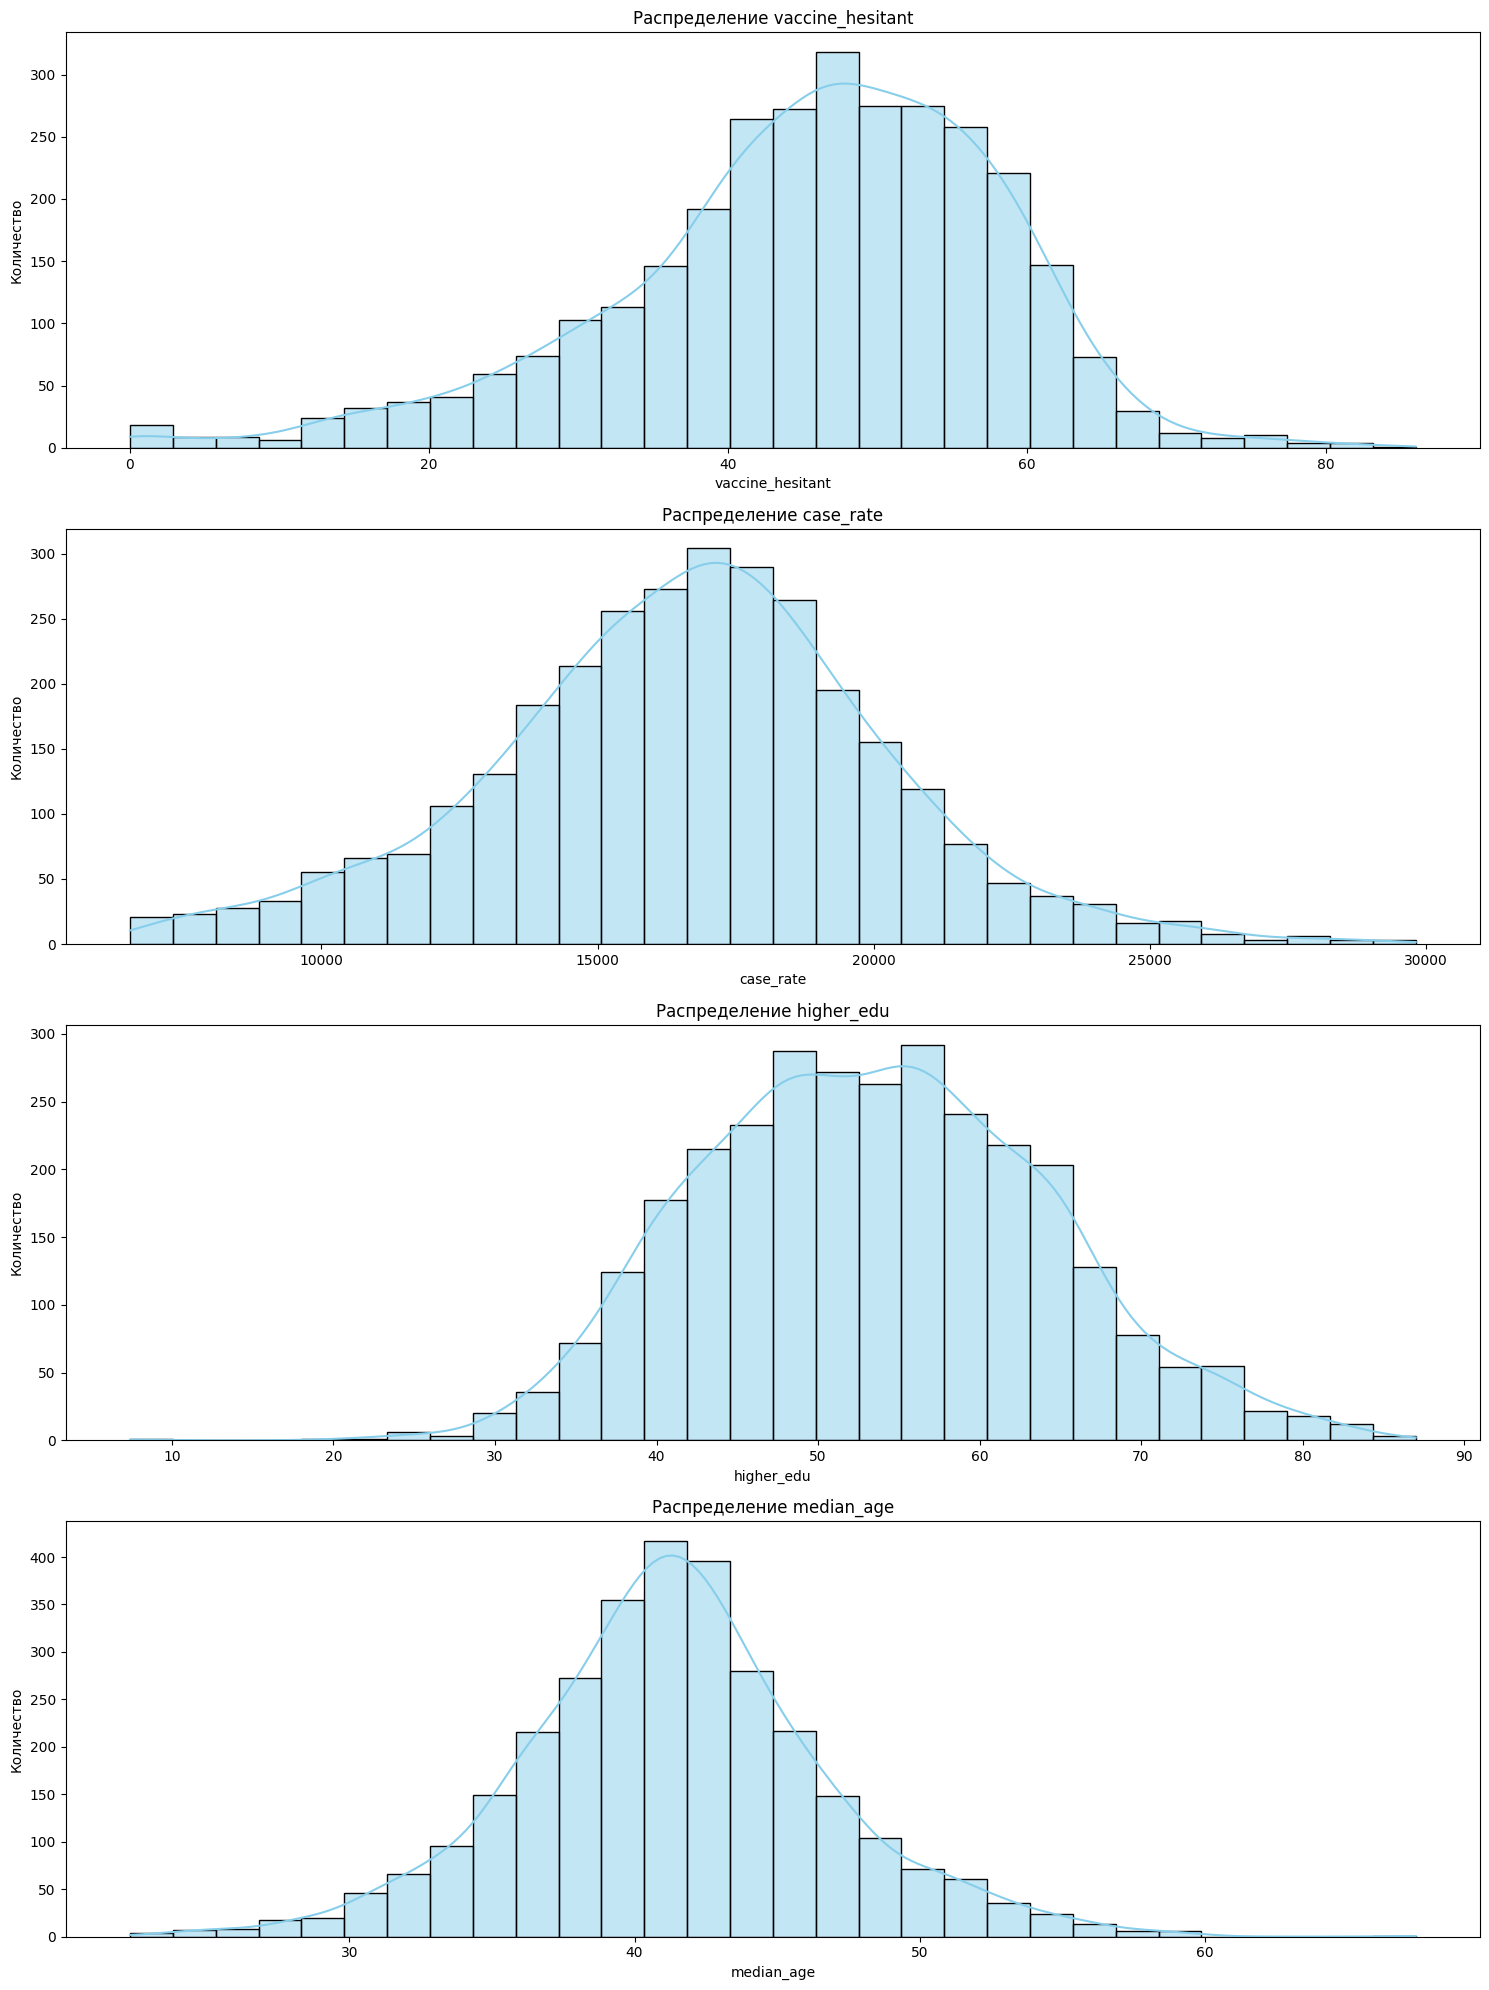

In [ ]:
col_hist = ['vaccine_hesitant', 'case_rate', 'higher_edu', 'median_age']

plt.figure(figsize =(15, 20))
for i, col in enumerate(col_hist):
    plt.subplot(len(col_hist),1,i+1)
    sns.histplot(data=df, x=col, bins=30, color='skyblue', kde=True)
    plt.title(f'Распределение {col}')
    plt.ylabel('Количество')
    plt.xlabel(col)
plt.tight_layout()
plt.show()


#### 5. Теоретические нормальные распределения vs настоящие данные

In [ ]:
teor_mean = [df[i].mean() for i in col_hist]
teor_std = [df[i].std() for i in col_hist]

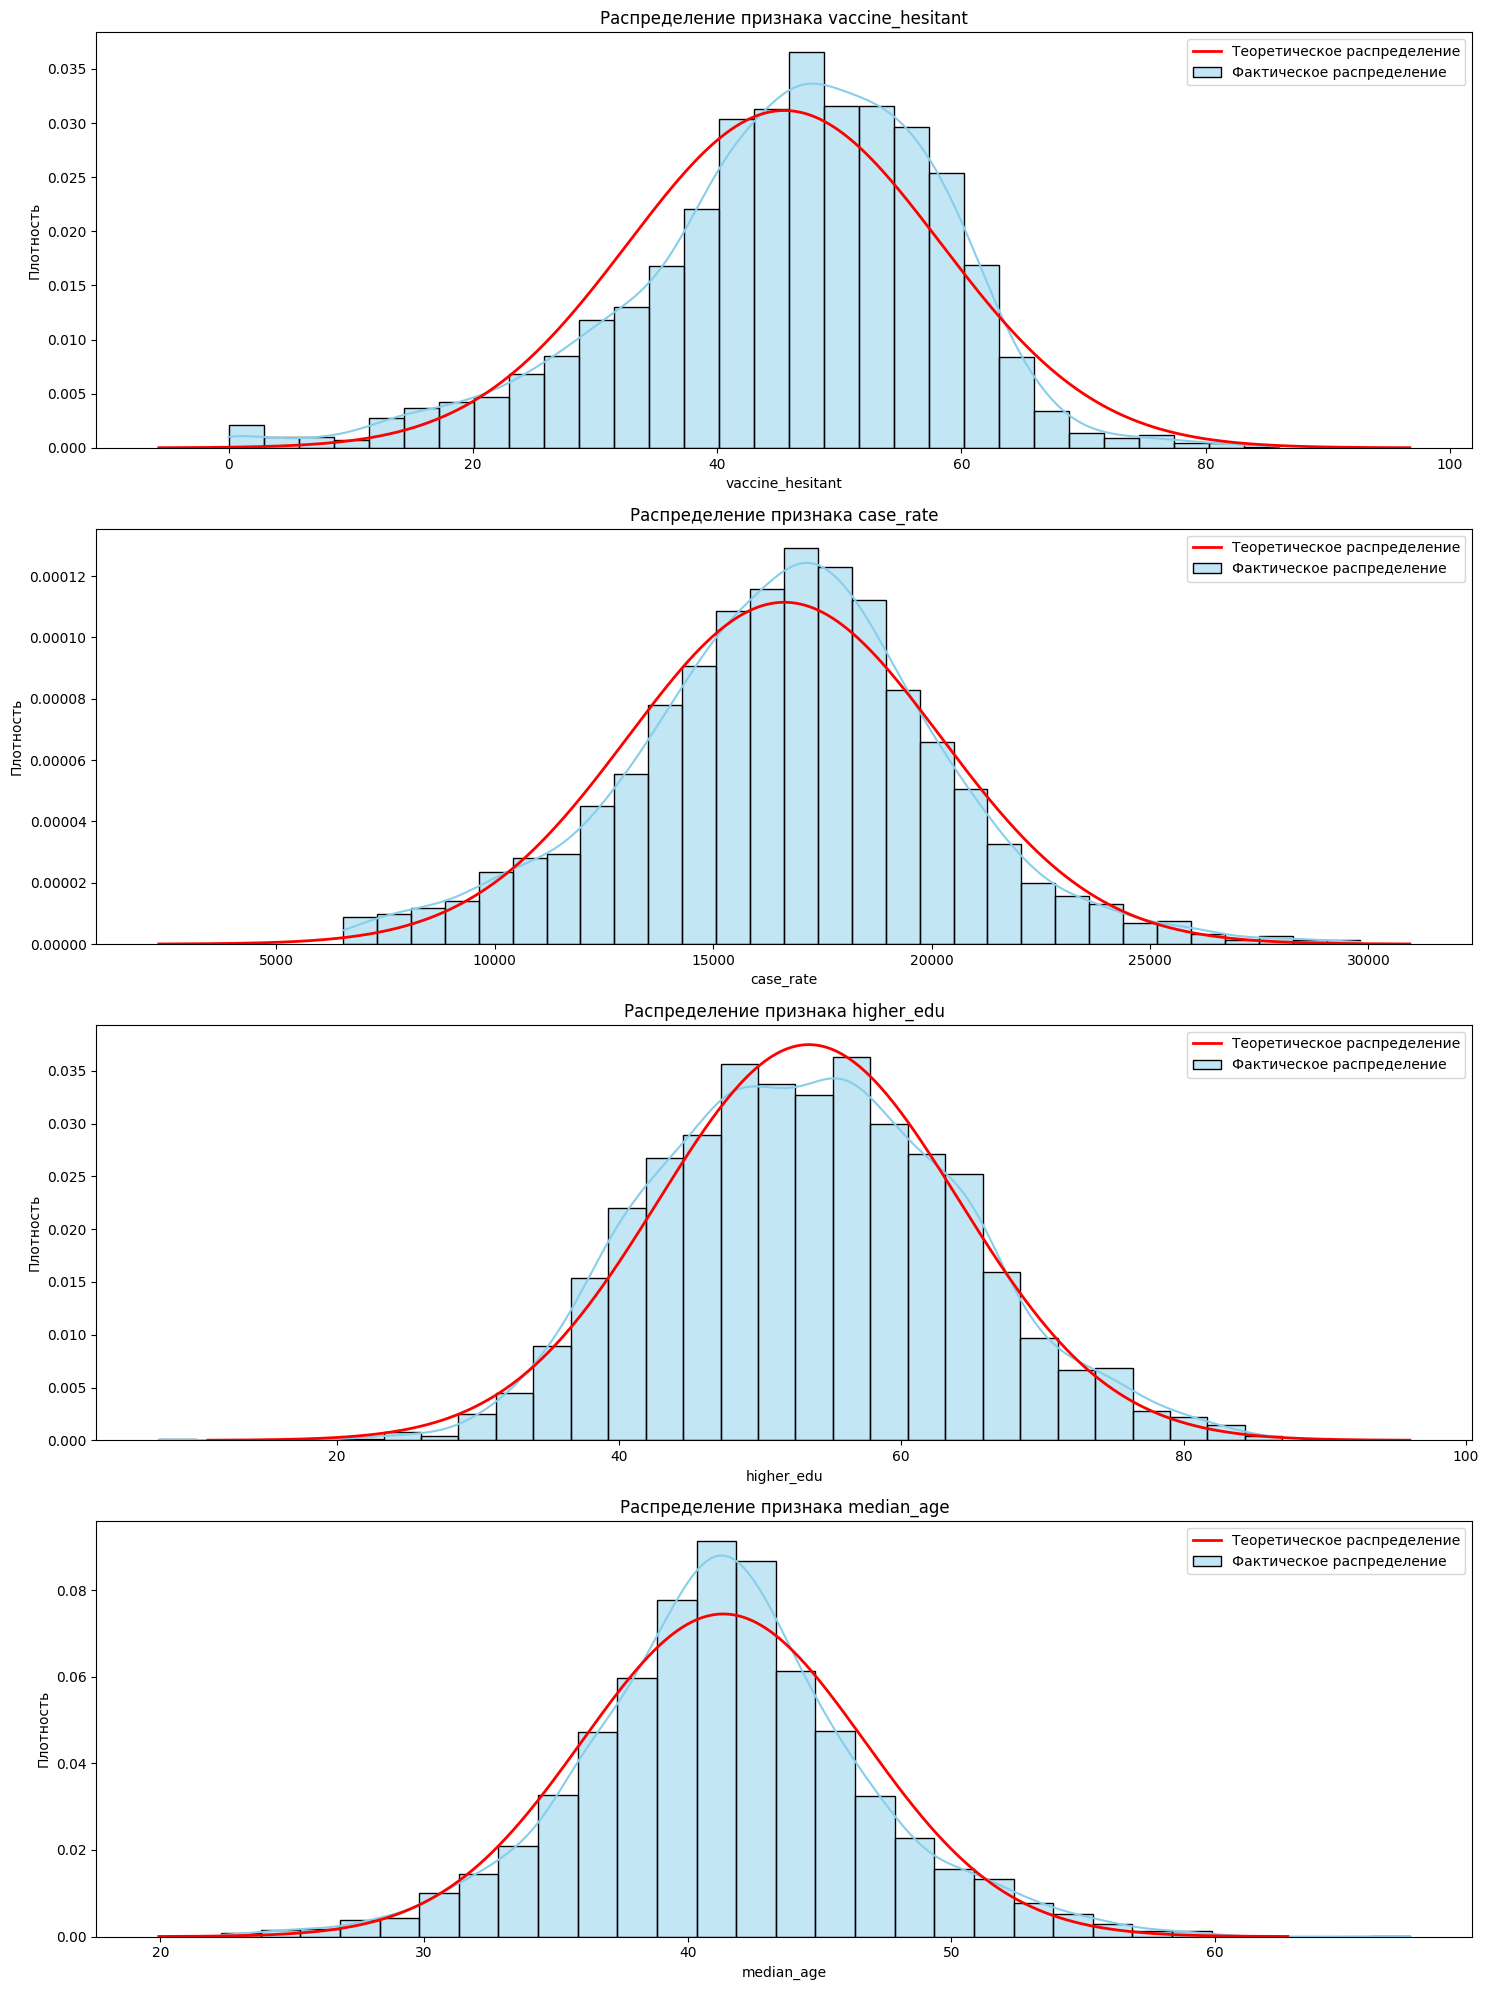

In [ ]:
plt.figure(figsize=(15,20))
for i, col in enumerate(col_hist):
    plt.subplot(len(col_hist),1,i+1)
    x = np.linspace(teor_mean[i] - 4 * teor_std[i], teor_mean[i] + 4 * teor_std[i], 1000)
    y = norm.pdf(x, loc=teor_mean[i], scale=teor_std[i])
    sns.histplot(data=df, x=col, bins=30, color='skyblue', kde=True, stat="density", label="Фактическое распределение")
    plt.plot(x, y, color="red", linewidth=2, label="Теоретическое распределение")
    plt.title(f"Распределение признака {col}")
    plt.xlabel(col)
    plt.ylabel("Плотность")
    plt.legend()
plt.tight_layout()
plt.show()

В целом на глаз неплохо похоже, но нужно смотреть по тесту

#### 6. Ящик с усами для столбцов vaccine_hesitant, case_rate, higher_edu и median_age

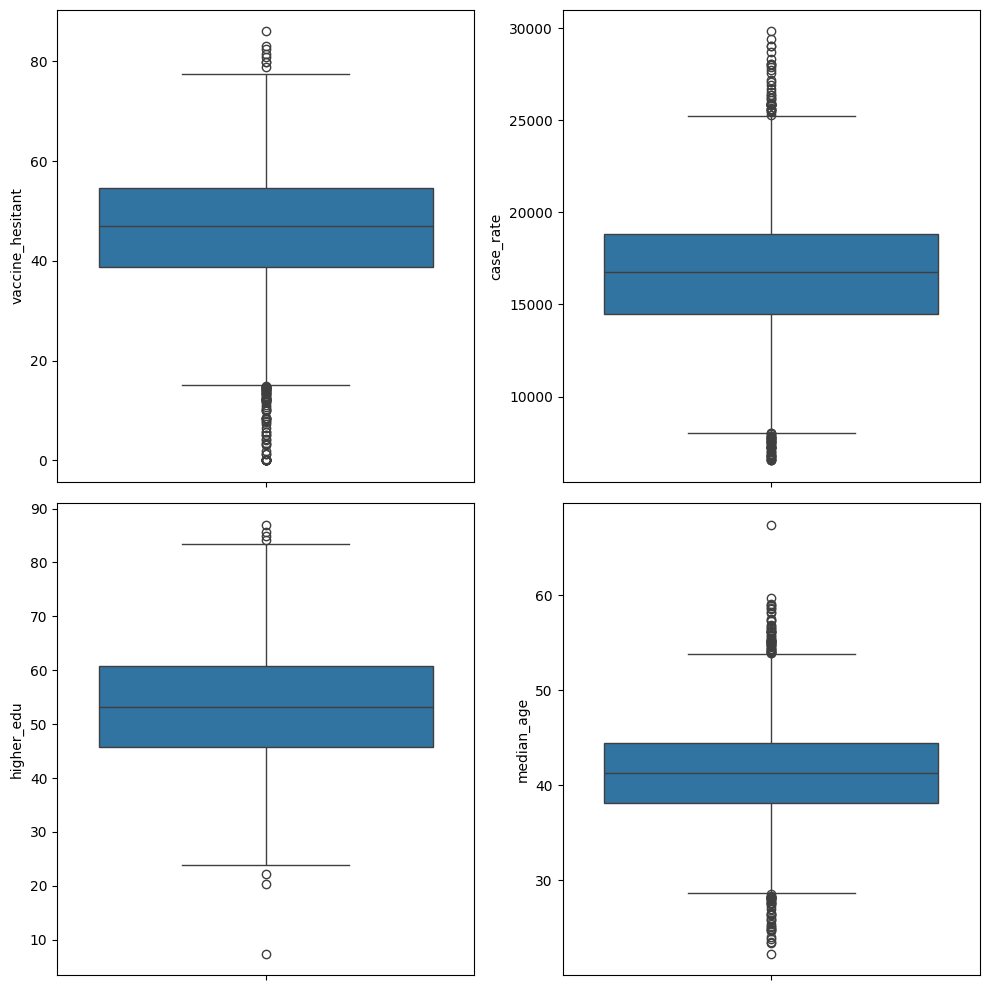

In [ ]:
n_cols = 2
n_rows = math.ceil(len(col_hist) / n_cols)

plt.figure(figsize=(10, 10))

for i, col in enumerate(col_hist):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=df, y=col)
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [ ]:
outliers_info = []

for col in col_hist:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers_count = df[
        (df[col] < lower_bound) | (df[col] > upper_bound)
    ][col].count()

    outliers_info.append({
        "column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outliers_count": outliers_count
    })

outliers_df = pd.DataFrame(outliers_info)

outliers_df

,column,Q1,Q3,IQR,lower_bound,upper_bound,outliers_count
0,vaccine_hesitant,38.715961,54.549219,15.833258,14.966075,78.299106,83
1,case_rate,14497.715060,18810.421090,4312.706030,8028.656015,25279.480135,80
2,higher_edu,45.700000,60.800000,15.100000,23.050000,83.450000,7
3,median_age,38.100000,44.400000,6.300000,28.650000,53.850000,88


Выбросы присутствуют во всех анализируемых признаках.   
Больше всего выбросов найдено в `median_age` — 88 наблюдений, затем в `vaccine_hesitant` — 83 и `case_rate` — 80.   
Минимальное количество выбросов наблюдается в признаке `higher_edu` — 7.

#### 7. Q-Q plot для столбцов vaccine_hesitant, case_rate, higher_edu и median_age

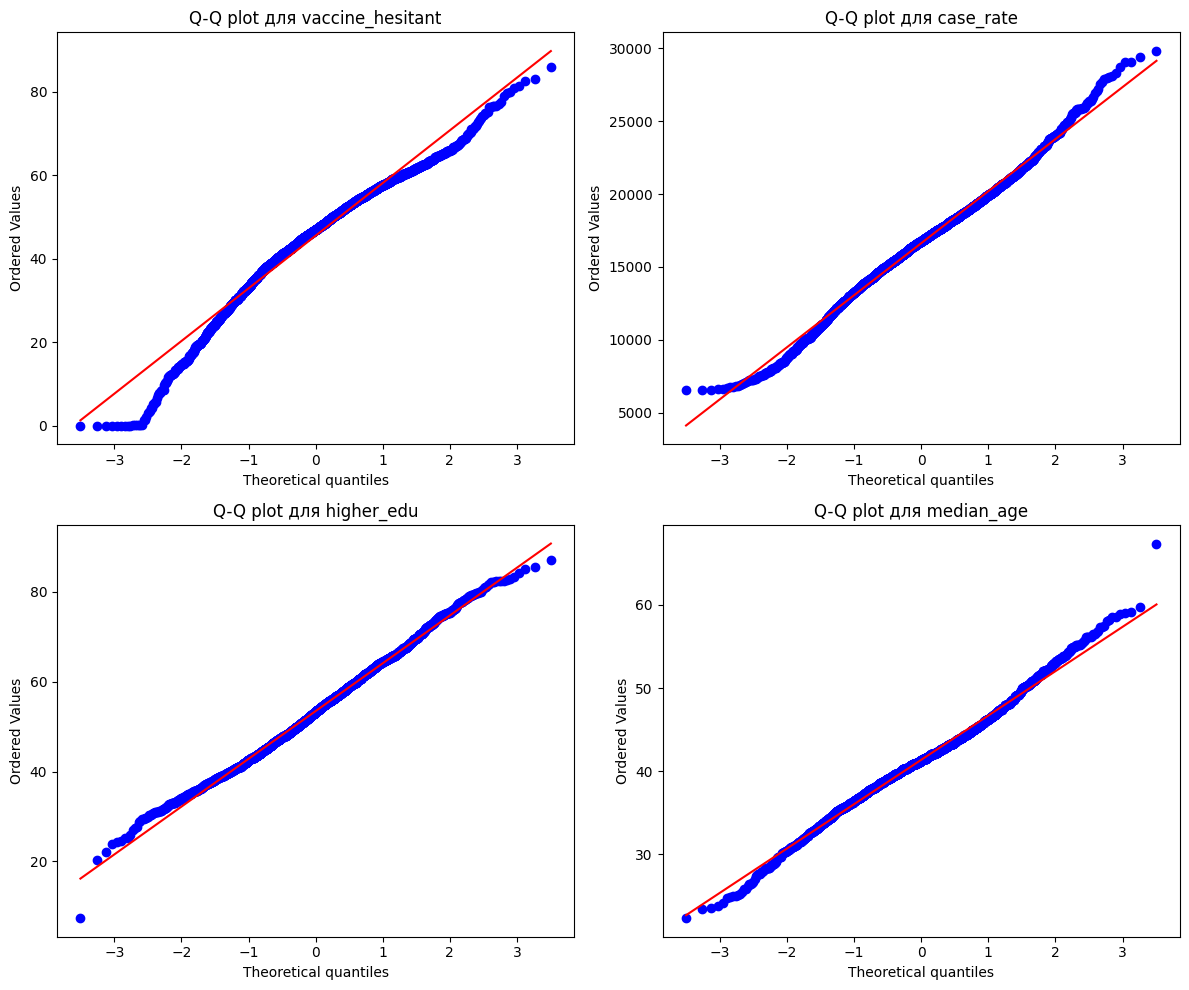

In [ ]:
plt.figure(figsize=(12, 10))

for i, col in enumerate(col_hist):
    plt.subplot(2, 2, i + 1)
    stats.probplot(
        df[col].dropna(),
        dist="norm",
        plot=plt
    )
    plt.title(f"Q-Q plot для {col}")

plt.tight_layout()
plt.show()

По Q-Q plot видно, что признаки не идеально соответствуют нормальному распределению.

Ближе всего к нормальному распределению находится `higher_edu`: точки в основном расположены около прямой.  
У `case_rate` и `median_age` есть заметные отклонения на краях распределения.  
Сильнее всего от нормального распределения отклоняется `vaccine_hesitant`, особенно в левой части графика.

Таким образом, наиболее близким к нормальному распределению выглядит `higher_edu`, а наименее — `vaccine_hesitant`.

#### 8. Тест Шапиро_Уилка на нормальность распределения

In [ ]:
alpha = 0.05

shapiro_results = []

for col in col_hist:
    stat, p_value = stats.shapiro(df[col].dropna())

    if p_value > alpha:
        result = "распределение похоже на нормальное"
    else:
        result = "распределение не является нормальным"

    shapiro_results.append({
        "column": col,
        "statistic": stat,
        "p_value": p_value,
        "result": result
    })

shapiro_results_df = pd.DataFrame(shapiro_results)
shapiro_results_df

,column,statistic,p_value,result
0,vaccine_hesitant,0.970836,2.161604e-24,распределение не является нормальным
1,case_rate,0.993888,5.643106e-10,распределение не является нормальным
2,higher_edu,0.996525,1.810664e-06,распределение не является нормальным
3,median_age,0.992764,3.381173e-11,распределение не является нормальным


#### 9. Выводы о нормальном распределении

В тесте Шапиро–Уилка проверялась гипотеза о нормальности распределения данных.  
   
Нулевая гипотеза H₀: данные в столбце распределены нормально.    
Альтернативная гипотеза H₁: данные в столбце не распределены нормально.  
   
Уровень значимости был принят равным 0.05.     
Если `p-value` меньше 0.05, то нулевая гипотеза отвергается.    
   
По результатам теста:

- для `vaccine_hesitant` p-value = 2.16e-24;  
- для `case_rate` p-value = 5.64e-10;  
- для `higher_edu` p-value = 1.81e-06;
- для `median_age` p-value = 3.38e-11.
   
Во всех случаях `p-value < 0.05`, поэтому для каждого из четырех признаков нулевая гипотеза о нормальном распределении отвергается.   
   
Следовательно, признаки `vaccine_hesitant`, `case_rate`, `higher_edu` и `median_age` статистически значимо отличаются от нормального распределения.    

<a id="task-2"></a>
## 2. Бутстрап и доверительные интервалы

### Алгоритм бутстрапа

Бутстрап — это метод оценки статистик и доверительных интервалов с помощью многократного повторного сэмплирования данных.

Алгоритм бутстрапа:

1. Берем исходную выборку данных.
2. Много раз создаем новые выборки из исходной выборки.
3. Каждая новая выборка формируется случайно с возвращением, то есть один и тот же объект может попасть в выборку несколько раз.
4. Для каждой бутстрап-выборки считаем нужную статистику: среднее, медиану, стандартное отклонение и т. д.
5. Получаем распределение этих статистик.
6. Для построения 95% доверительного интервала берем 2.5-й и 97.5-й процентили полученного распределения.

Так как бутстрап не требует нормальности данных, его можно использовать для признаков, распределение которых отличается от нормального.

In [ ]:
col_bootstrap = [
    "vaccine_hesitant",
    "case_rate",
    "higher_edu",
    "median_age",
]

n_bootstrap = 1000
sample_size = 100
alpha = 0.05

rng = np.random.default_rng(42)

In [ ]:
bootstrap_results = []

for col in col_bootstrap:
    values = df[col].dropna().to_numpy()

    bootstrap_samples = rng.choice(
        values,
        size=(n_bootstrap, sample_size),
        replace=True
    )

    bootstrap_means = bootstrap_samples.mean(axis=1)
    bootstrap_medians = np.median(bootstrap_samples, axis=1)
    bootstrap_stds = bootstrap_samples.std(axis=1, ddof=1)

    bootstrap_results.append({
        "column": col,

        "sample_mean": values.mean(),
        "mean_ci_lower": np.percentile(bootstrap_means, 2.5),
        "mean_ci_upper": np.percentile(bootstrap_means, 97.5),

        "sample_median": np.median(values),
        "median_ci_lower": np.percentile(bootstrap_medians, 2.5),
        "median_ci_upper": np.percentile(bootstrap_medians, 97.5),

        "sample_std": values.std(ddof=1),
        "std_ci_lower": np.percentile(bootstrap_stds, 2.5),
        "std_ci_upper": np.percentile(bootstrap_stds, 97.5),
    })

bootstrap_results_df = pd.DataFrame(bootstrap_results)

bootstrap_results_df.round(3)

,column,sample_mean,mean_ci_lower,mean_ci_upper,sample_median,median_ci_lower,median_ci_upper,sample_std,std_ci_lower,std_ci_upper
0,vaccine_hesitant,45.502,42.960,47.795,46.944,44.292,49.700,12.804,10.701,14.716
1,case_rate,16631.160,15910.047,17306.650,16769.460,15908.866,17499.388,3578.834,3016.172,4138.588
2,higher_edu,53.453,51.426,55.524,53.200,50.449,56.000,10.646,9.322,12.246
3,median_age,41.354,40.277,42.404,41.300,40.150,42.350,5.354,4.509,6.193


По результатам бутстрапа были построены 95% доверительные интервалы для среднего, медианы и стандартного отклонения.

Самые широкие интервалы наблюдаются у `case_rate`, что связано с большим разбросом значений.  
Более узкие интервалы получились у `higher_edu` и `median_age`, значит эти оценки более стабильны.

Все выборочные значения среднего, медианы и стандартного отклонения находятся внутри своих доверительных интервалов.

Бутстрап позволил оценить возможные значения параметров генеральной совокупности без предположения о нормальности данных.

<a id="task-3"></a>
## 3. Центральная предельная теорема и доверительные интервалы

#### 1. Бутстрапированные средние для vaccine_hesitant

In [ ]:
column = "vaccine_hesitant"

values = df[column].dropna().to_numpy()

n_bootstrap = 1000
sample_size = 100

rng = np.random.default_rng(42)

bootstrap_samples = rng.choice(
    values,
    size=(n_bootstrap, sample_size),
    replace=True
)

bootstrap_means_vaccine = bootstrap_samples.mean(axis=1)

#### 2. На этом списке из 1000 средних:  
#### Гистограмма частот

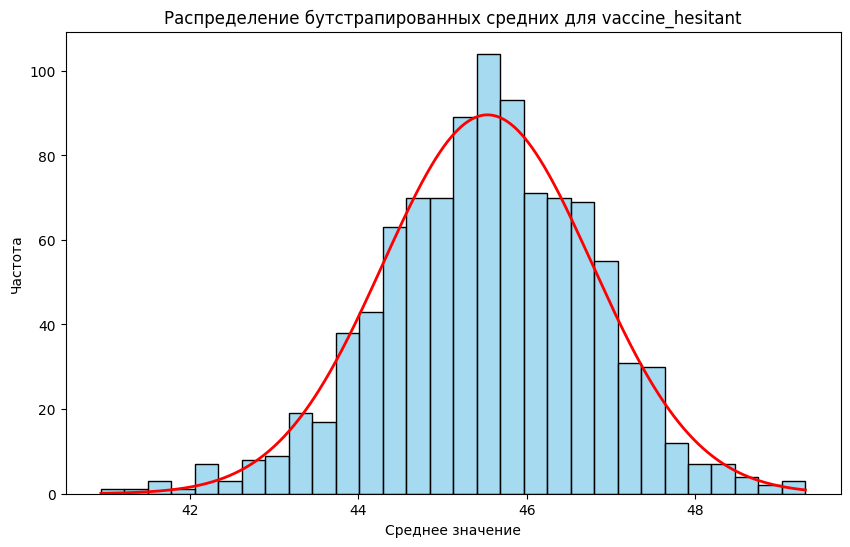

In [ ]:
mean_bootstrap = bootstrap_means_vaccine.mean()
std_bootstrap = bootstrap_means_vaccine.std(ddof=1)

bins = 30
x = np.linspace(
    bootstrap_means_vaccine.min(),
    bootstrap_means_vaccine.max(),
    1000
)

bin_width = (
    bootstrap_means_vaccine.max() - bootstrap_means_vaccine.min()
) / bins

y = norm.pdf(
    x,
    loc=mean_bootstrap,
    scale=std_bootstrap
) * len(bootstrap_means_vaccine) * bin_width

plt.figure(figsize=(10, 6))

sns.histplot(
    bootstrap_means_vaccine,
    bins=bins,
    color="skyblue"
)

plt.plot(x, y, color="red", linewidth=2)

plt.title("Распределение бутстрапированных средних для vaccine_hesitant")
plt.xlabel("Среднее значение")
plt.ylabel("Частота")

plt.show()

#### Q-Q plot

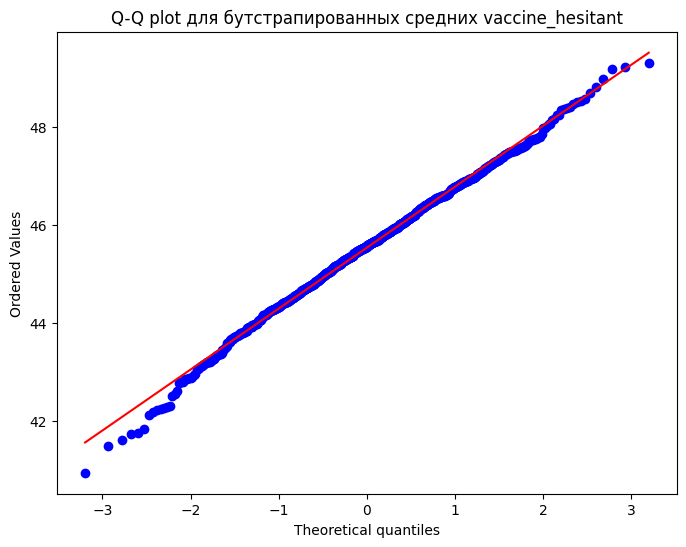

In [ ]:
plt.figure(figsize=(8, 6))

stats.probplot(
    bootstrap_means_vaccine,
    dist="norm",
    plot=plt
)

plt.title("Q-Q plot для бутстрапированных средних vaccine_hesitant")
plt.show()

#### Тест Шапиро–Уилка

In [ ]:
alpha = 0.05

stat, p_value = stats.shapiro(bootstrap_means_vaccine)

print(f"statistic = {stat:.5f}")
print(f"p-value = {p_value:.5f}")

if p_value > alpha:
    print("Нет оснований отвергать нормальность распределения")
else:
    print("Распределение не является нормальным")

statistic = 0.99675
p-value = 0.03757
Распределение не является нормальным


#### 3. Вывод о нормальности данного списка средних

Распределение бутстрапированных средних для `vaccine_hesitant` визуально похоже на нормальное: гистограмма имеет колоколообразную форму, а точки на Q-Q plot в основном лежат около прямой.

Однако по тесту Шапиро–Уилка `p-value = 0.03757`, что меньше 0.05. Поэтому формально нулевая гипотеза о нормальности отвергается.

Таким образом, распределение средних близко к нормальному визуально, но статистический тест показывает небольшое отклонение от нормальности.

### Центральная предельная теорема

Центральная предельная теорема говорит, что если многократно брать выборки одинакового размера и считать их средние, то распределение этих средних будет стремиться к нормальному распределению.

Это работает даже тогда, когда исходные данные распределены не нормально. Поэтому средние по выборкам для `vaccine_hesitant` могут быть близки к нормальному распределению, хотя сам столбец `vaccine_hesitant` нормальным не является.

#### 4. Средние по 60 непересекающимся выборкам по 50 элементов

In [ ]:
n_samples = 60
sample_size = 50
total_size = n_samples * sample_size

if len(values) < total_size:
    print("Недостаточно данных для 60 непересекающихся выборок по 50 элементов")
else:
    unique_sample = rng.choice(
        values,
        size=total_size,
        replace=False
    )

    independent_samples = unique_sample.reshape(n_samples, sample_size)

    independent_means = independent_samples.mean(axis=1)

    independent_means[:10]

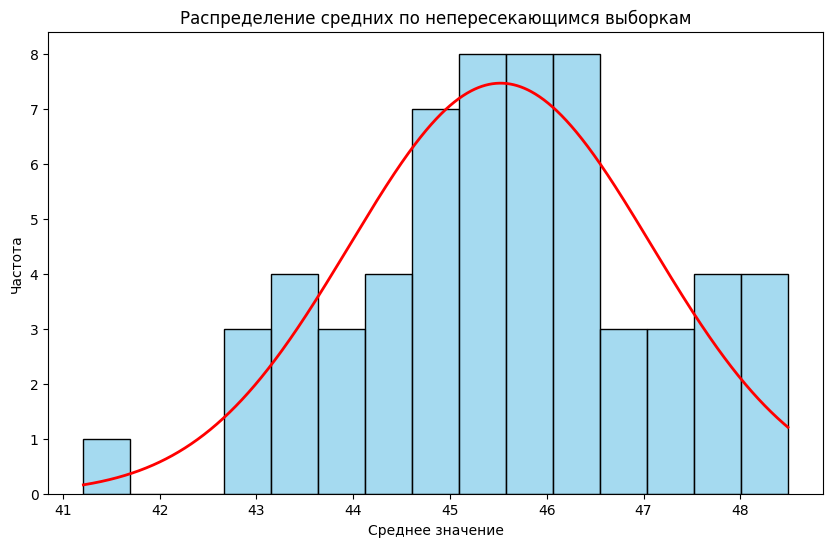

In [ ]:
mean_independent = independent_means.mean()
std_independent = independent_means.std(ddof=1)

bins = 15

x = np.linspace(
    independent_means.min(),
    independent_means.max(),
    1000
)

bin_width = (
    independent_means.max() - independent_means.min()
) / bins

y = norm.pdf(
    x,
    loc=mean_independent,
    scale=std_independent
) * len(independent_means) * bin_width

plt.figure(figsize=(10, 6))

sns.histplot(
    independent_means,
    bins=bins,
    color="skyblue"
)

plt.plot(x, y, color="red", linewidth=2)

plt.title("Распределение средних по непересекающимся выборкам")
plt.xlabel("Среднее значение")
plt.ylabel("Частота")

plt.show()

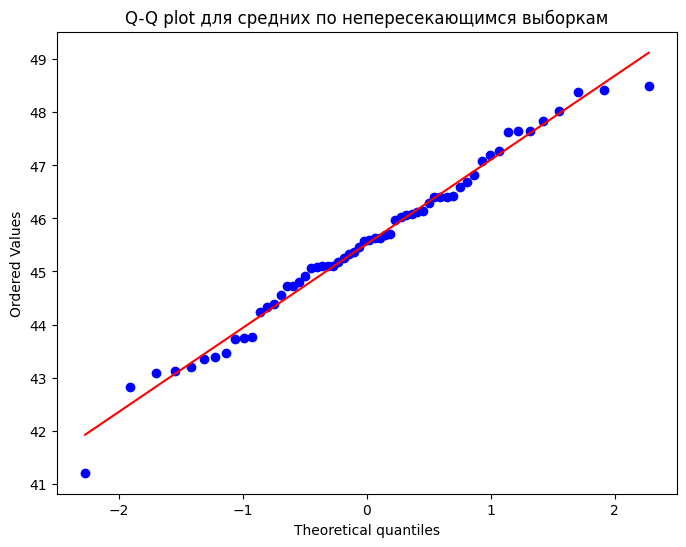

In [ ]:
plt.figure(figsize=(8, 6))

stats.probplot(
    independent_means,
    dist="norm",
    plot=plt
)

plt.title("Q-Q plot для средних по непересекающимся выборкам")
plt.show()

In [ ]:
stat, p_value = stats.shapiro(independent_means)

print(f"statistic = {stat:.5f}")
print(f"p-value = {p_value:.5f}")

if p_value > alpha:
    print("Нет оснований отвергать нормальность распределения")
else:
    print("Распределение не является нормальным")

statistic = 0.98465
p-value = 0.65199
Нет оснований отвергать нормальность распределения


Для 60 непересекающихся выборок по 50 элементов распределение средних визуально похоже на нормальное: гистограмма имеет колоколообразную форму, а точки на Q-Q plot расположены близко к прямой.

По тесту Шапиро–Уилка `p-value = 0.65199`, что больше 0.05. Поэтому нет оснований отвергать нулевую гипотезу о нормальности.

Распределение средних по непересекающимся выборкам можно считать близким к нормальному, что подтверждает действие центральной предельной теоремы.

#### 5. Многократная проверка для непересекающихся выборок

In [ ]:
p_values = []

for _ in range(100):
    unique_sample = rng.choice(
        values,
        size=total_size,
        replace=False
    )

    independent_samples = unique_sample.reshape(n_samples, sample_size)
    independent_means = independent_samples.mean(axis=1)

    _, p_value = stats.shapiro(independent_means)
    p_values.append(p_value)

p_values = np.array(p_values)

normal_count = (p_values > alpha).sum()

print(f"Количество проверок с p-value > 0.05: {normal_count}")
print(f"Количество всех проверок: {len(p_values)}")
print(f"Доля успешных проверок: {normal_count / len(p_values):.2f}")

Количество проверок с p-value > 0.05: 90
Количество всех проверок: 100
Доля успешных проверок: 0.90


При многократном формировании 60 непересекающихся выборок по 50 элементов тест Шапиро–Уилка в 90 случаях из 100 показал `p-value > 0.05`.

Это означает, что в большинстве запусков нет оснований отвергать нормальность распределения средних.

Доля успешных проверок составила 0.90, что подтверждает действие центральной предельной теоремы: распределение выборочных средних обычно становится близким к нормальному.

#### 6. Доверительные интервалы для среднего через стандартную ошибку

In [ ]:
columns = [
    "vaccine_hesitant",
    "case_rate",
    "higher_edu",
    "median_age",
]

alpha = 0.05

sem_ci_results = []

for col in columns:
    values = df[col].dropna().to_numpy()

    n = len(values)
    mean_value = values.mean()
    std_value = values.std(ddof=1)
    se_value = std_value / np.sqrt(n)

    t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)

    ci_lower = mean_value - t_critical * se_value
    ci_upper = mean_value + t_critical * se_value

    sem_ci_results.append({
        "column": col,
        "mean": mean_value,
        "std": std_value,
        "se": se_value,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
    })

sem_ci_results_df = pd.DataFrame(sem_ci_results)

sem_ci_results_df.round(3)

,column,mean,std,se,ci_lower,ci_upper
0,vaccine_hesitant,45.502,12.804,0.232,45.046,45.958
1,case_rate,16631.160,3578.834,64.962,16503.785,16758.535
2,higher_edu,53.453,10.646,0.193,53.074,53.832
3,median_age,41.354,5.354,0.097,41.163,41.544


Для признаков `vaccine_hesitant`, `case_rate`, `higher_edu` и `median_age` были построены 95% доверительные интервалы для среднего через стандартную ошибку.

Полученные интервалы:
- `vaccine_hesitant`: от 45.046 до 45.958;
- `case_rate`: от 16503.785 до 16758.535;
- `higher_edu`: от 53.074 до 53.832;
- `median_age`: от 41.163 до 41.544.

<a id="task-4"></a>
## 4. T-распределение

#### 1. Делим данные на две группы

In [ ]:
vaccine_median = df["vaccine_hesitant"].median()

low_vaccine_group = df.loc[
    df["vaccine_hesitant"] < vaccine_median,
    "case_rate"
].dropna()

high_vaccine_group = df.loc[
    df["vaccine_hesitant"] > vaccine_median,
    "case_rate"
].dropna()

print(f"Медиана vaccine_hesitant: {vaccine_median:.3f}")
print(f"Размер группы ниже медианы: {len(low_vaccine_group)}")
print(f"Размер группы выше медианы: {len(high_vaccine_group)}")

Медиана vaccine_hesitant: 46.944
Размер группы ниже медианы: 1517
Размер группы выше медианы: 1517


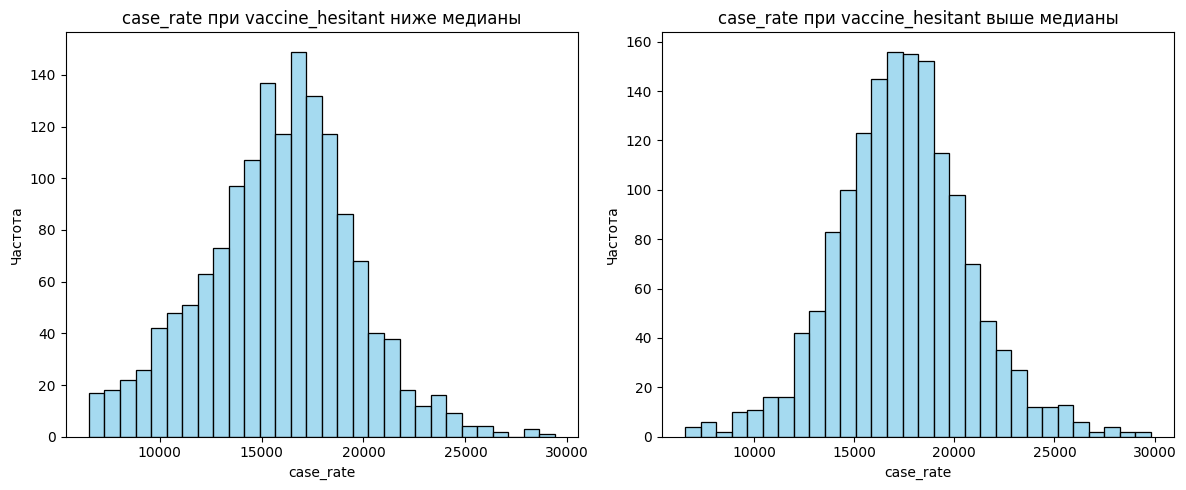

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(low_vaccine_group, bins=30, color="skyblue")
plt.title("case_rate при vaccine_hesitant ниже медианы")
plt.xlabel("case_rate")
plt.ylabel("Частота")

plt.subplot(1, 2, 2)
sns.histplot(high_vaccine_group, bins=30, color="skyblue")
plt.title("case_rate при vaccine_hesitant выше медианы")
plt.xlabel("case_rate")
plt.ylabel("Частота")

plt.tight_layout()
plt.show()

In [ ]:
alpha = 0.05

groups = {
    "vaccine_hesitant ниже медианы": low_vaccine_group,
    "vaccine_hesitant выше медианы": high_vaccine_group,
}

shapiro_group_results = []

for group_name, group_data in groups.items():
    stat, p_value = stats.shapiro(group_data)

    if p_value > alpha:
        result = "распределение похоже на нормальное"
    else:
        result = "распределение не является нормальным"

    shapiro_group_results.append({
        "group": group_name,
        "statistic": stat,
        "p_value": p_value,
        "result": result,
    })

shapiro_group_results_df = pd.DataFrame(shapiro_group_results)

shapiro_group_results_df

,group,statistic,p_value,result
0,vaccine_hesitant ниже медианы,0.993939,0.000007,распределение не является нормальным
1,vaccine_hesitant выше медианы,0.992994,0.000001,распределение не является нормальным


#### 2. Подбор параметров t-распределения

In [ ]:
t_distribution_results = []

for group_name, group_data in groups.items():
    df_t, loc_t, scale_t = stats.t.fit(group_data)

    t_distribution_results.append({
        "group": group_name,
        "df": df_t,
        "loc": loc_t,
        "scale": scale_t,
    })

t_distribution_results_df = pd.DataFrame(t_distribution_results)

t_distribution_results_df

,group,df,loc,scale
0,vaccine_hesitant ниже медианы,2.620387e+06,15842.911150,3677.280886
1,vaccine_hesitant выше медианы,6.021239e+06,17419.165415,3294.132818


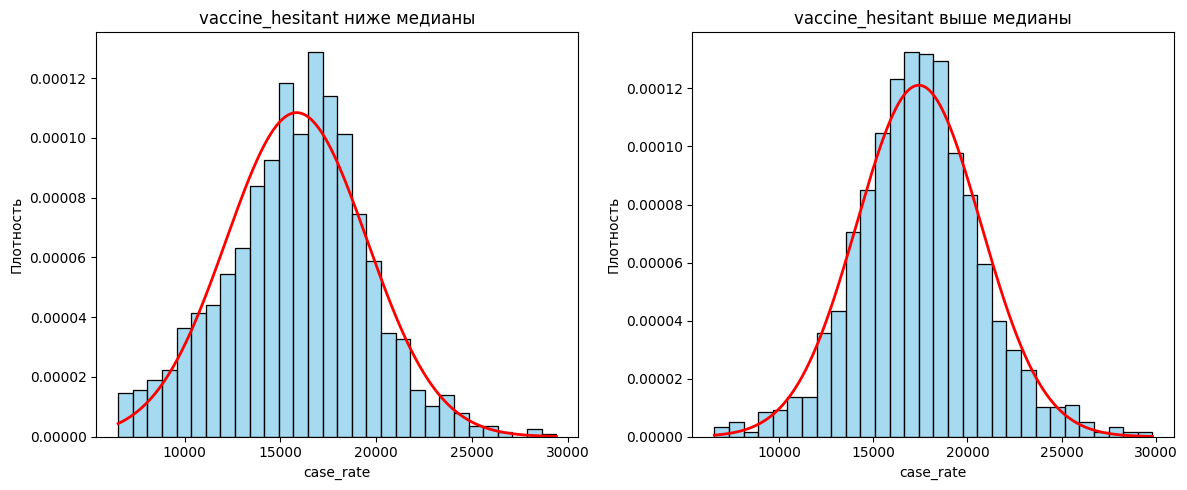

In [ ]:
plt.figure(figsize=(12, 5))

for i, (group_name, group_data) in enumerate(groups.items()):
    df_t, loc_t, scale_t = stats.t.fit(group_data)

    x = np.linspace(group_data.min(), group_data.max(), 1000)
    y = stats.t.pdf(x, df=df_t, loc=loc_t, scale=scale_t)

    plt.subplot(1, 2, i + 1)

    sns.histplot(
        group_data,
        bins=30,
        stat="density",
        color="skyblue"
    )

    plt.plot(x, y, color="red", linewidth=2)
    plt.title(group_name)
    plt.xlabel("case_rate")
    plt.ylabel("Плотность")

plt.tight_layout()
plt.show()

#### 3. Тест Колмогорова–Смирнова

In [ ]:
ks_results = []

for group_name, group_data in groups.items():
    df_t, loc_t, scale_t = stats.t.fit(group_data)

    stat, p_value = stats.kstest(
        group_data,
        "t",
        args=(df_t, loc_t, scale_t)
    )

    if p_value > alpha:
        result = "нет оснований отвергать t-распределение"
    else:
        result = "данные не относятся к t-распределению"

    ks_results.append({
        "group": group_name,
        "statistic": stat,
        "p_value": p_value,
        "result": result,
    })

ks_results_df = pd.DataFrame(ks_results)

ks_results_df

,group,statistic,p_value,result
0,vaccine_hesitant ниже медианы,0.031809,0.090878,нет оснований отвергать t-распределение
1,vaccine_hesitant выше медианы,0.027801,0.188026,нет оснований отвергать t-распределение


По результатам теста Колмогорова–Смирнова для обеих групп `p-value` больше 0.05:

- для группы с `vaccine_hesitant` ниже медианы: `p-value = 0.090878`;
- для группы с `vaccine_hesitant` выше медианы: `p-value = 0.188026`.

Следовательно, нет оснований отвергать гипотезу о том, что данные в обеих группах соответствуют подобранному t-распределению.

Распределение `case_rate` в обеих группах можно считать согласующимся с t-распределением.

<a id="task-5"></a>
## 5. T-критерий

In [ ]:
low_vaccine_group = df.loc[
    df["vaccine_hesitant"] < vaccine_median,
    "case_rate"
].dropna()

high_vaccine_group = df.loc[
    df["vaccine_hesitant"] > vaccine_median,
    "case_rate"
].dropna()

#### 1. Тест Левене

In [ ]:
alpha = 0.05

levene_stat, levene_p_value = stats.levene(
    low_vaccine_group,
    high_vaccine_group
)

print(f"Levene statistic = {levene_stat:.5f}")
print(f"Levene p-value = {levene_p_value:.5f}")

if levene_p_value > alpha:
    equal_var = True
    test_name = "t-тест Стьюдента"
else:
    equal_var = False
    test_name = "t-тест Уэлча"

print(f"Выбранный тест: {test_name}")

Levene statistic = 19.41764
Levene p-value = 0.00001
Выбранный тест: t-тест Уэлча


#### 2. t-тест Уэлча

In [ ]:
low_vaccine_group = df.loc[
    df["vaccine_hesitant"] < vaccine_median,
    "case_rate"
].dropna()

high_vaccine_group = df.loc[
    df["vaccine_hesitant"] > vaccine_median,
    "case_rate"
].dropna()

In [ ]:
t_stat_builtin, p_value_builtin = stats.ttest_ind(
    low_vaccine_group,
    high_vaccine_group,
    equal_var=False
)

print(f"t-statistic = {t_stat_builtin:.5f}")
print(f"p-value = {p_value_builtin:.5f}")

if p_value_builtin < alpha:
    print("H0 отвергается: средние статистически значимо различаются")
else:
    print("Нет оснований отвергать H0: значимых различий не найдено")

t-statistic = -12.43125
p-value = 0.00000
H0 отвергается: средние статистически значимо различаются


#### 3. Ручная реализация t-теста Уэлча:

In [ ]:
def manual_t_test(sample_1, sample_2):
    sample_1 = np.array(sample_1)
    sample_2 = np.array(sample_2)

    n1 = len(sample_1)
    n2 = len(sample_2)

    mean_1 = sample_1.mean()
    mean_2 = sample_2.mean()

    var_1 = sample_1.var(ddof=1)
    var_2 = sample_2.var(ddof=1)

    standard_error = np.sqrt(var_1 / n1 + var_2 / n2)

    t_statistic = (mean_1 - mean_2) / standard_error

    degrees_of_freedom = (
        (var_1 / n1 + var_2 / n2) ** 2
        / (
            (var_1 / n1) ** 2 / (n1 - 1)
            + (var_2 / n2) ** 2 / (n2 - 1)
        )
    )

    p_value = 2 * stats.t.sf(
        abs(t_statistic),
        df=degrees_of_freedom
    )

    return t_statistic, degrees_of_freedom, p_value

In [ ]:
t_stat_manual, df_manual, p_value_manual = manual_t_test(
    low_vaccine_group,
    high_vaccine_group
)

print(f"t-statistic = {t_stat_manual:.5f}")
print(f"degrees of freedom = {df_manual:.5f}")
print(f"p-value = {p_value_manual:.5f}")

if p_value_manual < alpha:
    print("H0 отвергается: средние статистически значимо различаются")
else:
    print("Нет оснований отвергать H0: значимых различий не найдено")

t-statistic = -12.43125
degrees of freedom = 2996.01860
p-value = 0.00000
H0 отвергается: средние статистически значимо различаются


#### Сравнение:

In [ ]:
t_test_comparison = pd.DataFrame({
    "method": ["scipy.stats", "manual_t_test"],
    "t_statistic": [t_stat_builtin, t_stat_manual],
    "p_value": [p_value_builtin, p_value_manual],
})

t_test_comparison

,method,t_statistic,p_value
0,scipy.stats,-12.431255,1.245230e-34
1,manual_t_test,-12.431255,1.245230e-34


По результатам теста Левене `p-value < 0.05`, поэтому гипотеза о равенстве дисперсий отвергается. Значит, для сравнения средних был выбран t-тест Уэлча.

Встроенный t-тест и ручная функция `manual_t_test` дали одинаковые или практически одинаковые значения t-критерия и p-value.

Так как `p-value < 0.05`, нулевая гипотеза отвергается. Следовательно, средние значения `case_rate` в группах с низким и высоким уровнем недоверия к вакцинации статистически значимо различаются.

<a id="task-6"></a>
## 6. U-критерий Мана–Уитни

### Гипотезы

H₀: средний процент нерешительных в отношении вакцинации в городских и сельских округах одинаков.

H₁: средний процент нерешительных в отношении вакцинации в городских и сельских округах различается.

In [ ]:
area_col = "area_type"

df[area_col].value_counts()

area_type
Rural    1930
Urban    1105
Name: count, dtype: int64

In [ ]:
urban_group = df.loc[
    df[area_col]== "Urban",
    "vaccine_hesitant"
].dropna()

rural_group = df.loc[
    df[area_col] == "Rural",
    "vaccine_hesitant"
].dropna()

print(f"Размер городской группы: {len(urban_group)}")
print(f"Размер сельской группы: {len(rural_group)}")

Размер городской группы: 1105
Размер сельской группы: 1930


#### 1. Проверка нормальности: тест Шапиро–Уилка

In [ ]:
alpha = 0.05

groups = {
    "urban": urban_group,
    "rural": rural_group,
}

normality_results = []

for group_name, group_data in groups.items():
    stat, p_value = stats.shapiro(group_data)

    result = (
        "распределение похоже на нормальное"
        if p_value > alpha
        else "распределение не является нормальным"
    )

    normality_results.append({
        "group": group_name,
        "statistic": stat,
        "p_value": p_value,
        "result": result,
    })

normality_results_df = pd.DataFrame(normality_results)

normality_results_df

,group,statistic,p_value,result
0,urban,0.979526,2.243450e-11,распределение не является нормальным
1,rural,0.959230,7.511000e-23,распределение не является нормальным


#### 2. Проверка на t-распределение

In [ ]:
t_fit_results = []

for group_name, group_data in groups.items():
    df_t, loc_t, scale_t = stats.t.fit(group_data)

    ks_stat, ks_p_value = stats.kstest(
        group_data,
        "t",
        args=(df_t, loc_t, scale_t)
    )

    result = (
        "нет оснований отвергать t-распределение"
        if ks_p_value > alpha
        else "данные не относятся к t-распределению"
    )

    t_fit_results.append({
        "group": group_name,
        "df": df_t,
        "loc": loc_t,
        "scale": scale_t,
        "ks_statistic": ks_stat,
        "p_value": ks_p_value,
        "result": result,
    })

t_fit_results_df = pd.DataFrame(t_fit_results)

t_fit_results_df

,group,df,loc,scale,ks_statistic,p_value,result
0,urban,28.354843,39.166211,12.084664,0.046895,0.015002,данные не относятся к t-распределению
1,rural,5.062528,50.136592,8.923975,0.035370,0.015605,данные не относятся к t-распределению


#### 3. Встроенный U-тест Мана–Уитни

In [ ]:
u_stat_builtin, p_value_builtin = stats.mannwhitneyu(
    urban_group,
    rural_group,
    alternative="two-sided",
    method="asymptotic",
    use_continuity=False
)

print(f"U-statistic = {u_stat_builtin:.5f}")
print(f"p-value = {p_value_builtin:.5f}")

if p_value_builtin < alpha:
    print("H0 отвергается: различия статистически значимы")
else:
    print("Нет оснований отвергать H0: значимых различий не найдено")

U-statistic = 553414.00000
p-value = 0.00000
H0 отвергается: различия статистически значимы


#### 4. Ручная реализация manual_u_test

In [ ]:
def get_average_ranks(values):
    values = np.asarray(values)
    order = np.argsort(values)
    sorted_values = values[order]

    ranks = np.empty(len(values), dtype=float)

    i = 0
    while i < len(values):
        j = i

        while j + 1 < len(values) and sorted_values[j + 1] == sorted_values[i]:
            j += 1

        average_rank = (i + 1 + j + 1) / 2
        ranks[order[i:j + 1]] = average_rank

        i = j + 1

    return ranks

In [ ]:
def manual_u_test(sample_1, sample_2):
    sample_1 = np.asarray(sample_1)
    sample_2 = np.asarray(sample_2)

    n1 = len(sample_1)
    n2 = len(sample_2)

    combined = np.concatenate([sample_1, sample_2])
    ranks = get_average_ranks(combined)

    ranks_1 = ranks[:n1]

    rank_sum_1 = ranks_1.sum()

    u1 = rank_sum_1 - n1 * (n1 + 1) / 2
    u2 = n1 * n2 - u1

    u_statistic = u1

    mean_u = n1 * n2 / 2

    _, tie_counts = np.unique(combined, return_counts=True)

    tie_correction = np.sum(tie_counts ** 3 - tie_counts)

    n = n1 + n2

    var_u = (
        n1 * n2 / 12
        * ((n + 1) - tie_correction / (n * (n - 1)))
    )

    z_score = (u_statistic - mean_u) / np.sqrt(var_u)

    p_value = 2 * stats.norm.sf(abs(z_score))

    return u_statistic, z_score, p_value

In [ ]:
u_stat_manual, z_score_manual, p_value_manual = manual_u_test(
    urban_group,
    rural_group
)

print(f"U-statistic = {u_stat_manual:.5f}")
print(f"Z-score = {z_score_manual:.5f}")
print(f"p-value = {p_value_manual:.5f}")

if p_value_manual < alpha:
    print("H0 отвергается: различия статистически значимы")
else:
    print("Нет оснований отвергать H0: значимых различий не найдено")

U-statistic = 553414.00000
Z-score = -22.08116
p-value = 0.00000
H0 отвергается: различия статистически значимы


Сравнение:

In [ ]:
u_test_comparison = pd.DataFrame({
    "method": ["scipy.stats", "manual_u_test"],
    "u_statistic": [u_stat_builtin, u_stat_manual],
    "p_value": [p_value_builtin, p_value_manual],
})

u_test_comparison

,method,u_statistic,p_value
0,scipy.stats,553414.0,4.795748e-108
1,manual_u_test,553414.0,4.795748e-108


По результатам теста Шапиро–Уилка данные в обеих группах не являются нормально распределенными: для `urban` и `rural` значение `p-value < 0.05`.

Также по тесту Колмогорова–Смирнова обе группы не относятся к подобранному t-распределению, так как в обоих случаях `p-value < 0.05`.

Следовательно, параметрический t-тест использовать не стоит. Для проверки гипотезы был выбран непараметрический U-критерий Мана–Уитни.

По результатам U-критерия Мана–Уитни:

- `U-statistic = 553414.0`;
- `p-value = 4.80e-108`.

Значение `p-value` значительно меньше уровня значимости 0.05, поэтому нулевая гипотеза отвергается.

Следовательно, процент нерешительных в отношении вакцинации в городских и сельских округах статистически значимо различается.

Результаты встроенного теста `stats.mannwhitneyu` и ручной функции `manual_u_test` совпали.

<a id="task-7"></a>
## 7. Корреляция Пирсона

Корреляция Пирсона показывает силу и направление линейной связи между двумя числовыми признаками.

Значение корреляции находится в диапазоне от -1 до 1:

- ближе к 1 — сильная прямая линейная связь;
- ближе к -1 — сильная обратная линейная связь;
- около 0 — линейная связь слабая или отсутствует.

In [ ]:
x = df["higher_edu"].dropna()
y = df.loc[x.index, "vaccine_hesitant"].dropna()

common_index = x.index.intersection(y.index)

x = df.loc[common_index, "higher_edu"].to_numpy()
y = df.loc[common_index, "vaccine_hesitant"].to_numpy()

#### Встроенная функция

In [ ]:
pearson_stat, pearson_p_value = stats.pearsonr(x, y)

print(f"Pearson correlation = {pearson_stat:.5f}")
print(f"p-value = {pearson_p_value:.5f}")

Pearson correlation = -0.47785
p-value = 0.00000


#### Ручная функция

In [ ]:
def pearson_correlation(sample_1, sample_2):
    sample_1 = np.asarray(sample_1)
    sample_2 = np.asarray(sample_2)

    mean_1 = sample_1.mean()
    mean_2 = sample_2.mean()

    deviation_1 = sample_1 - mean_1
    deviation_2 = sample_2 - mean_2

    numerator = np.sum(deviation_1 * deviation_2)

    denominator = np.sqrt(
        np.sum(deviation_1 ** 2) * np.sum(deviation_2 ** 2)
    )

    correlation = numerator / denominator

    return correlation

In [ ]:
pearson_manual = pearson_correlation(x, y)

print(f"Manual Pearson correlation = {pearson_manual:.5f}")

Manual Pearson correlation = -0.47785


#### Сравнение

In [ ]:
pearson_comparison = pd.DataFrame({
    "method": ["stats.pearsonr", "pearson_correlation"],
    "correlation": [pearson_stat, pearson_manual],
})

pearson_comparison

,method,correlation
0,stats.pearsonr,-0.477851
1,pearson_correlation,-0.477851


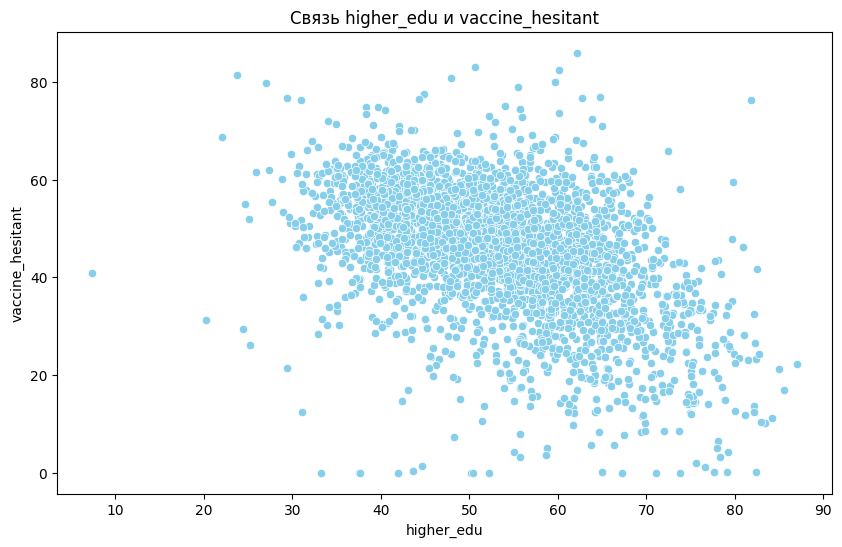

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="higher_edu",
    y="vaccine_hesitant",
    color="skyblue"
)

plt.title("Связь higher_edu и vaccine_hesitant")
plt.xlabel("higher_edu")
plt.ylabel("vaccine_hesitant")

plt.show()

Корреляция Пирсона между `higher_edu` и `vaccine_hesitant` равна `-0.47785`.

Это говорит об умеренной отрицательной линейной связи: при росте `higher_edu` процент нерешительных в отношении вакцинации в среднем снижается.

На scatter plot также видно нисходящее направление облака точек, что подтверждает отрицательную связь между признаками.

Результаты встроенной функции и ручной функции совпали.

<a id="task-8"></a>
## 8. Корреляция Спирмена

In [ ]:
corr_columns = ["higher_edu", "vaccine_hesitant"]

normality_corr_results = []

for col in corr_columns:
    stat, p_value = stats.shapiro(df[col].dropna())

    result = (
        "распределение похоже на нормальное"
        if p_value > alpha
        else "распределение не является нормальным"
    )

    normality_corr_results.append({
        "column": col,
        "statistic": stat,
        "p_value": p_value,
        "result": result,
    })

normality_corr_results_df = pd.DataFrame(normality_corr_results)

normality_corr_results_df

,column,statistic,p_value,result
0,higher_edu,0.996525,1.810664e-06,распределение не является нормальным
1,vaccine_hesitant,0.970836,2.161604e-24,распределение не является нормальным


In [ ]:
t_corr_results = []

for col in corr_columns:
    values = df[col].dropna()

    df_t, loc_t, scale_t = stats.t.fit(values)

    ks_stat, ks_p_value = stats.kstest(
        values,
        "t",
        args=(df_t, loc_t, scale_t)
    )

    result = (
        "нет оснований отвергать t-распределение"
        if ks_p_value > alpha
        else "данные не относятся к t-распределению"
    )

    t_corr_results.append({
        "column": col,
        "df": df_t,
        "loc": loc_t,
        "scale": scale_t,
        "ks_statistic": ks_stat,
        "p_value": ks_p_value,
        "result": result,
    })

t_corr_results_df = pd.DataFrame(t_corr_results)

t_corr_results_df

,column,df,loc,scale,ks_statistic,p_value,result
0,higher_edu,5.003232e+06,53.452649,10.644255,0.027332,0.021068,данные не относятся к t-распределению
1,vaccine_hesitant,7.777737e+00,46.296716,11.088815,0.040001,0.000118,данные не относятся к t-распределению


#### Встроенная корреляция Спирмена

In [ ]:
spearman_stat, spearman_p_value = stats.spearmanr(x, y)

print(f"Spearman correlation = {spearman_stat:.5f}")
print(f"p-value = {spearman_p_value:.5f}")

Spearman correlation = -0.47732
p-value = 0.00000


#### Ручная функция Спирмена

In [ ]:
def get_average_ranks(values):
    values = np.asarray(values)
    order = np.argsort(values)
    sorted_values = values[order]

    ranks = np.empty(len(values), dtype=float)

    i = 0
    while i < len(values):
        j = i

        while j + 1 < len(values) and sorted_values[j + 1] == sorted_values[i]:
            j += 1

        average_rank = (i + 1 + j + 1) / 2
        ranks[order[i:j + 1]] = average_rank

        i = j + 1

    return ranks

In [ ]:
def spearman_correlation(sample_1, sample_2):
    sample_1 = np.asarray(sample_1)
    sample_2 = np.asarray(sample_2)

    ranks_1 = get_average_ranks(sample_1)
    ranks_2 = get_average_ranks(sample_2)

    correlation = pearson_correlation(ranks_1, ranks_2)

    return correlation

In [ ]:
spearman_manual = spearman_correlation(x, y)

print(f"Manual Spearman correlation = {spearman_manual:.5f}")

Manual Spearman correlation = -0.47732


#### Сравнение

In [ ]:
spearman_comparison = pd.DataFrame({
    "method": ["stats.spearmanr", "spearman_correlation"],
    "correlation": [spearman_stat, spearman_manual],
})

spearman_comparison

,method,correlation
0,stats.spearmanr,-0.477324
1,spearman_correlation,-0.477324


По результатам теста Шапиро–Уилка признаки `higher_edu` и `vaccine_hesitant` не являются нормально распределенными.

Проверка на t-распределение также показала, что оба признака не относятся к t-распределению, так как `p-value < 0.05`.

Поэтому корректнее использовать корреляцию Спирмена.

Корреляция Спирмена равна `-0.47732`, что также говорит об умеренной отрицательной связи между признаками. Значение `p-value` меньше 0.05, значит связь статистически значима.

Вывод не изменился: между `higher_edu` и `vaccine_hesitant` есть умеренная отрицательная связь.